
### Basic Data Plotting

One of the most fundamental tasks in data analysis/modeling is to read data from files and plot them. In this section, we will learn how to read data from files and plot them using `matplotlib`.

Let's begin by importing the necessary libraries.


In [1]:
import csv
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

We will use the `csv` library to read data from files, `matplotlib` to plot data, `scipy` to fit data to a function, and `numpy` to perform numerical operations.

Let's write a function to read data from a CSV file. The function takes the filename as input and returns five lists: the (string) header label for each column in the data file, the x data, the y data, the error in x values, and the error in y values. The function assumes that the first row of the CSV file contains the column headers.

In [2]:
def read_data(filename):
    x = []
    y = []
    dx = []
    dy = []

    with open(filename, 'r') as file:
        reader = csv.reader(file)
        headers = next(reader, None)
        for row in reader:
            x.append(float(row[0]))
            y.append(float(row[1]))
            dx.append(float(row[2]))
            dy.append(float(row[3]))

    return headers, x, y, dx, dy

Next, we write the main program. We read the data using the function above and then plot the measurements with their $x$ and $y$ error bars, appropriate axis labels, and a title. We also set the lower limit of the $y$-axis to zero. Logarithmic $x$ or $y$ scales can be enabled when they are appropriate for the data.

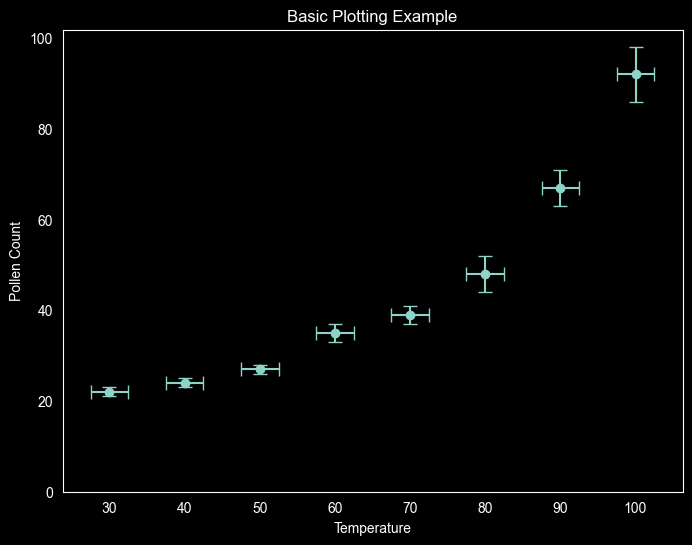

In [3]:
# Step 1:  Read the data into appropriate data structures
file_name = "testdata.csv"
header_values, xi, yi, dxi, dyi = read_data(file_name)

# print(header_values)
# print(xi, yi, dxi, dyi)

# Step 2: Basic plot of the data with error bars, plot title, and axis labels
fig, ax = plt.subplots(1,1, figsize=(8, 6))
ax.errorbar(xi, yi, xerr=dxi, yerr=dyi, fmt='o', label="Pollen Count Data", capsize=5.0)
ax.set_title("Basic Plotting Example")
ax.set_xlabel(header_values[0])
ax.set_ylabel(header_values[1])

# Make sure lower limit of y-axis is zero!
ax.set_ylim(0)
ax.grid()

# Possibly, choose logarithmic x and/or y scales.
# plt.xscale('log')
# plt.yscale('log')

Now, we can fit the data!  We define an appropriate fitting function (a quadratic in this case...), and then use the `curve_fit` function from `scipy` to fit the data.  We also print out the fit parameters and their uncertainties, and the covariance matrix.

In [4]:
# Step 3a: Define a quadratic fit function
def fitfunction(x, *param):
    return param[0]*x*x + param[1]*x + param[2]

# Step 3b:  Fit the data
init_vals = [0 for x in range(3)]
popt, pcov = curve_fit(fitfunction, xi, yi, p0=init_vals, sigma=dyi, absolute_sigma=False)

perr = np.sqrt(np.diag(pcov))

print(popt)
print(perr)
print(pcov)

[ 1.29744082e-02 -8.19654253e-01  3.54309138e+01]
[2.01583763e-03 2.22152158e-01 5.69286319e+00]
[[ 4.06360137e-06 -4.39474173e-04  1.07166140e-02]
 [-4.39474173e-04  4.93515811e-02 -1.24178408e+00]
 [ 1.07166140e-02 -1.24178408e+00  3.24086913e+01]]


Extract the fitted parameters and their uncertainties and display them in a more readable form. The parameter uncertainties are the square roots of the diagonal elements of the covariance matrix.

In [5]:
a = popt[0]
b = popt[1]
c = popt[2]
da = perr[0]
db = perr[1]
dc = perr[2]
print(f'Fit Result: y = ({a:.5f} +/- {da:.5f})x^2 + ({b:.5f} +/- {db:.5f})x + ({c:.5f} +/- {dc:.5f})')

Fit Result: y = (0.01297 +/- 0.00202)x^2 + (-0.81965 +/- 0.22215)x + (35.43091 +/- 5.69286)


Plot the fit result on top of the data.

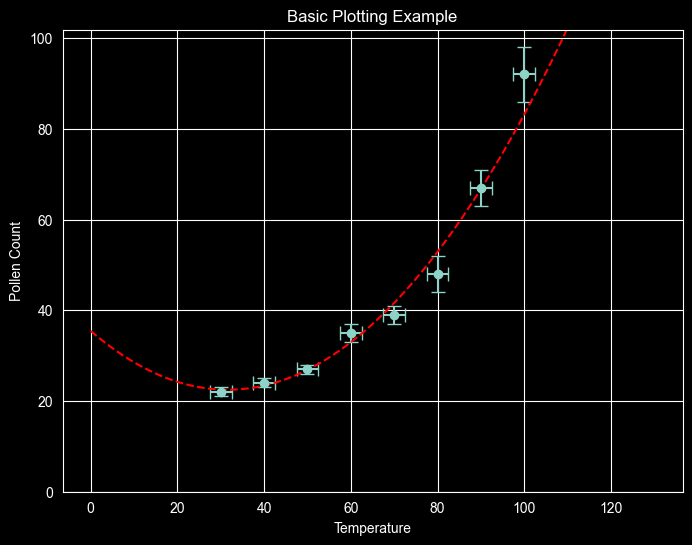

In [6]:
# Step 3d:  Plot the fit result
xlow = min(xi) - 30
xhigh = max(xi) + 30
xfit = np.linspace(xlow, xhigh, 100)
yfit = fitfunction(xfit,*popt)

ax.plot(xfit,yfit,'r--', label = f"Quadratic Fit: \ny = ({a:.4f} +/- {da:.4f})x^2 + \n({b:.2f} +/- {db:.2f})x + \n({c:.2f} +/- {dc:.2f})")
ax.grid()

fig


## Plot a one-sigma uncertainty band

The covariance matrix describes both the uncertainty of each fitted parameter and the correlations among parameters. To propagate that information to the fitted curve, we draw many parameter vectors from the multivariate normal distribution defined by `popt` and `pcov`. Each parameter vector produces a possible fitted curve.

At every value of $x$, the 16th and 84th percentiles of these curves enclose the central 68% interval—approximately a one-standard-deviation band when the distribution is Gaussian. `fill_between` shades the region between those limits so the uncertainty is visible without adding two more curves that could be mistaken for additional fits.

This is a **fit-parameter uncertainty band**: it shows uncertainty in the estimated mean curve arising from uncertainty in the fitted coefficients. It is not a prediction interval for a new measurement. A prediction interval would also include the expected scatter of individual measurements about the model and would therefore generally be wider.

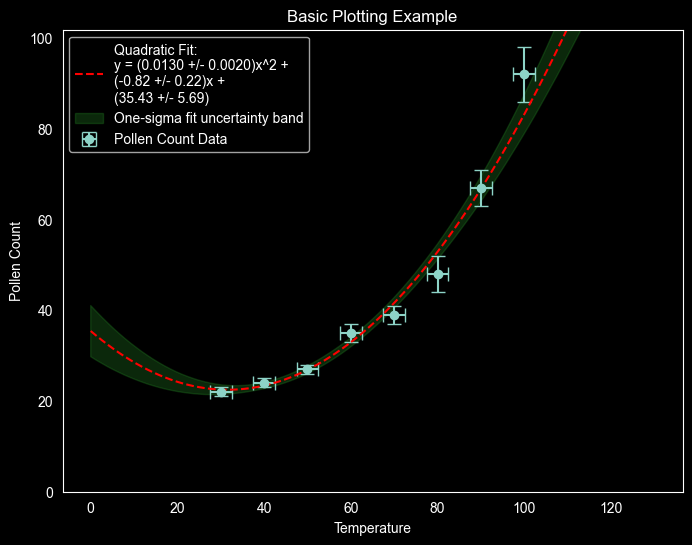

In [7]:
# Step 4:  Plot the error band
plot_error_band = True

if plot_error_band:
    # Use a fixed seed so the displayed band is reproducible.
    rng = np.random.default_rng(441)
    parameter_samples = rng.multivariate_normal(popt, pcov, size=10000)
    sampled_fits = np.asarray([fitfunction(xfit, *parameters)
                               for parameters in parameter_samples])

    lower = np.percentile(sampled_fits, 16.0, axis=0)
    upper = np.percentile(sampled_fits, 84.0, axis=0)
    ax.fill_between(xfit, lower, upper, color='tab:green', alpha=0.25,
                    label=r'One-sigma fit uncertainty band')

    ax.legend()
    ax.grid()

fig

## Visualizing $\chi^2$ in three-dimensional parameter space

A quadratic fit has three parameters,

$$f(x;a,b,c)=ax^2+bx+c,$$

so every possible fit corresponds to one point $(a,b,c)$ in a three-dimensional parameter space. At each point we can calculate

$$\chi^2(a,b,c)=\sum_i\left[\frac{y_i-f(x_i;a,b,c)}{\sigma_i}\right]^2.$$

$\chi^2$ is not itself a probability density: smaller values indicate better agreement with the data. Under the assumptions of independent Gaussian measurement errors and uniform prior parameter probabilities, it can be converted to a **relative likelihood density**:

$$\frac{L(a,b,c)}{L_{\max}}=\exp\left[-\frac{\chi^2(a,b,c)-\chi^2_{\min}}{2}\right].$$

The plot below evaluates this quantity on a regular three-dimensional grid. Each axis spans the best-fit value plus or minus its reported marginal one-sigma uncertainty. Point color, size, and opacity all represent relative likelihood: large, bright, opaque points are better fits, while small, faint points are poorer fits. The best-fit parameters are marked separately.

The tilted, elongated shape is important. It shows parameter correlation: changing one coefficient may be compensated by changing another. Consequently, the interval $a\pm\sigma_a$, $b\pm\sigma_b$, $c\pm\sigma_c$ should not be interpreted as a rectangular box in which every parameter combination is equally plausible.

In [9]:
## Step 5:  Visualize the relative likelihood in three-dimensional parameter space
%matplotlib qt

number_of_grid_points = 25
a_values = np.linspace(a-da, a+da, number_of_grid_points)
b_values = np.linspace(b-db, b+db, number_of_grid_points)
c_values = np.linspace(c-dc, c+dc, number_of_grid_points)
a_grid, b_grid, c_grid = np.meshgrid(
    a_values, b_values, c_values, indexing='ij'
)

x_data = np.asarray(xi)
y_data = np.asarray(yi)
y_uncertainty = np.asarray(dyi)

# The final array dimension indexes the measured data points.
grid_predictions = (a_grid[..., None]*x_data**2
                    + b_grid[..., None]*x_data
                    + c_grid[..., None])
chi2_grid = np.sum(
    ((y_data-grid_predictions)/y_uncertainty)**2, axis=-1
)
chi2_min = np.sum(
    ((y_data-fitfunction(x_data, *popt))/y_uncertainty)**2
)
delta_chi2 = np.maximum(chi2_grid-chi2_min, 0.0)
relative_likelihood = np.exp(-0.5*delta_chi2)

# Map likelihood to visual properties. Very unlikely points remain faint
# so that the correlated three-dimensional structure is still visible.
flat_likelihood = relative_likelihood.ravel()
point_colors = plt.colormaps['viridis'](flat_likelihood)
point_colors[:, 3] = 0.03+0.97*flat_likelihood
point_sizes = 2.0+45.0*flat_likelihood

fig_parameter_space = plt.figure(figsize=(10, 8))
ax_parameter_space = fig_parameter_space.add_subplot(
    111, projection='3d', computed_zorder=False
)
ax_parameter_space.scatter(
    a_grid.ravel(), b_grid.ravel(), c_grid.ravel(),
    c=point_colors, s=point_sizes, depthshade=False, zorder=1
)
ax_parameter_space.scatter(
    a, b, c, marker='*', s=250, color='tab:red', edgecolor='black',
    linewidth=0.8, label='Best fit', zorder=10
)

color_scale = plt.cm.ScalarMappable(
    norm=plt.Normalize(0.0, 1.0), cmap='viridis'
)
color_scale.set_array([])
colorbar = fig_parameter_space.colorbar(
    color_scale, ax=ax_parameter_space, pad=0.10, shrink=0.75
)
colorbar.set_label(r'Relative likelihood $e^{-\Delta\chi^2/2}$')

ax_parameter_space.set_xlabel(r'$a$ (quadratic coefficient)')
ax_parameter_space.set_ylabel(r'$b$ (linear coefficient)')
ax_parameter_space.set_zlabel(r'$c$ (constant coefficient)')
ax_parameter_space.set_title(
    r'Relative likelihood in quadratic-fit parameter space'
)
ax_parameter_space.legend()

fig_parameter_space.tight_layout()
